# Loan Status Prediction Project
## Introduction

This project focuses on predicting loan approval status using machine learning techniques. Financial institutions rely on accurate risk assessment before granting loans, and data-driven models can significantly improve decision-making.

In this analysis, we use a dataset containing applicant information such as income, education, marital status, and credit history to build a predictive model. The project follows a structured data science workflow: data loading, exploration, cleaning, visualization, feature engineering, and model building.

A Logistic Regression model is applied to classify whether a loan will be approved or not. The goal is to develop a simple yet effective predictive system that can assist in automating loan approval decisions.

## Importing pandas library
This cell imports pandas for data analysis.

In [2]:
import pandas as pd 

### Loading dataset
Loads dataset into a DataFrame.

In [3]:
loan=pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

### Viewing first rows
Displays first few rows of dataset.

In [4]:
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Checking dataset shape
Shows number of rows and columns.

In [5]:
loan.shape

(614, 13)

## Dataset info
Shows data types and missing values

In [6]:
loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## Statistical summary
Provides summary statistics.



In [8]:
loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Checking missing values
Counts missing values.

In [10]:
loan.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### Filling missing numerical values
Replaces missing numeric values with mean.

In [11]:
loan=loan.fillna(loan.mean(numeric_only=True))

### Final check
Ensures no missing values remain.

In [12]:
loan.isna().sum() 

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

### Visualizing categorical relationships
Shows relationships using bar charts.

<Axes: xlabel='Gender'>

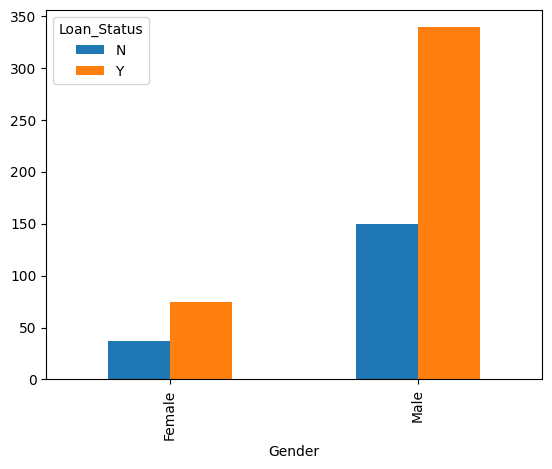

In [13]:
pd.crosstab(loan.Gender,loan.Loan_Status).plot(kind='bar') 

<Axes: xlabel='Married'>

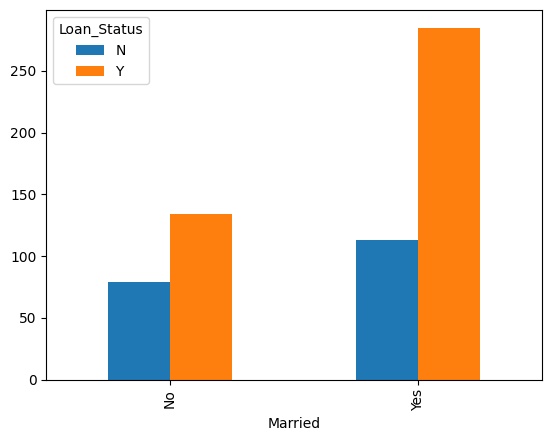

In [14]:
pd.crosstab(loan.Married,loan.Loan_Status).plot(kind='bar') 

<Axes: xlabel='Education'>

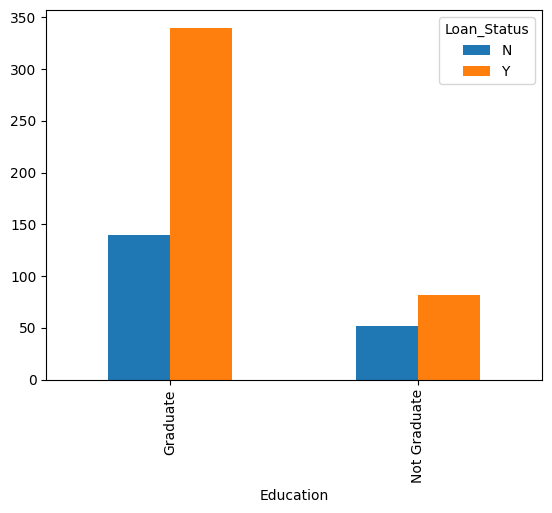

In [15]:
pd.crosstab(loan.Education,loan.Loan_Status).plot(kind='bar') 

### Importing visualization libraries
Imports matplotlib and seaborn.



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

### Boxplot visualization

Shows income vs loan status.

Text(0, 0.5, 'Loan Status')

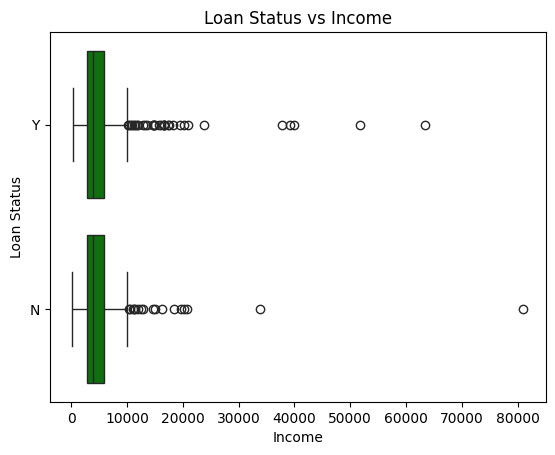

In [18]:
sns.boxplot(x='ApplicantIncome',y='Loan_Status', data=loan, color='green')
plt.title('Loan Status vs Income')
plt.xlabel('Income')
plt.ylabel('Loan Status') 

## Dropping unnecessary columns
Removes irrelevant columns.



In [19]:
final=loan.drop(columns=['Loan_ID']) 

In [20]:
dummies =pd.get_dummies(final, drop_first=True).astype('int64', 'floatb4')
dummies.head() 

C:\Users\All\AppData\Local\Temp\ipykernel_1776\3158307284.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  dummies =pd.get_dummies(final, drop_first=True).astype('int64', 'floatb4')


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0,146,360,1,1,0,0,0,0,0,0,0,1,1
1,4583,1508,128,360,1,1,1,1,0,0,0,0,0,0,0
2,3000,0,66,360,1,1,1,0,0,0,0,1,0,1,1
3,2583,2358,120,360,1,1,1,0,0,0,1,0,0,1,1
4,6000,0,141,360,1,1,0,0,0,0,0,0,0,1,1


### Splitting features and target
Separates X and Y.

In [21]:
x=dummies.drop(columns='Loan_Status_Y') 
y=dummies['Loan_Status_Y'] 

## Importing train-test split
Imports splitting function

### from sklearn.model_selection import train_test_split

Importing train-test split
Imports splitting function

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.1, random_state=3)

In [25]:
x_train.head(5) 

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
116,3167,2283,154,360,1,0,1,0,0,0,0,0,1,0
112,3572,4114,152,342,0,1,1,0,0,0,1,0,0,0
613,4583,0,133,360,0,0,0,0,0,0,0,1,1,0
254,16250,0,192,360,0,1,0,0,0,0,0,1,0,1
342,4554,1229,158,360,1,1,1,1,0,0,1,0,0,1


In [26]:
x_test.shape

(62, 14)

In [27]:
x_train.shape

(552, 14)

# Importing Logistic Regression
## training the model and testing it 

In [28]:
from sklearn.linear_model import LogisticRegression 

In [29]:
model=LogisticRegression()

In [30]:
model.fit(x_train, y_train)

C:\Users\All\anaconda3\envs\r_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
})


In [32]:
coefficients['Absolute'] = coefficients['Coefficient'].abs()

In [37]:

#Credit_History_1.0 has the highest positive coefficient, meaning applicants with a credit history are much more likely to be approved.
#Features with negative coefficients reduce the likelihood of loan approval.
#the magnitude of the coefficient indicates the strength of influence.


coefficients = coefficients.sort_values(by='Absolute', ascending=False)
print(coefficients.head(10))

                    Feature  Coefficient  Absolute
4            Credit_History     1.983943  1.983943
12  Property_Area_Semiurban     0.605304  0.605304
10   Education_Not Graduate    -0.425065  0.425065
6               Married_Yes     0.396131  0.396131
8              Dependents_2     0.248386  0.248386
7              Dependents_1    -0.156542  0.156542
9             Dependents_3+    -0.100716  0.100716
11        Self_Employed_Yes    -0.100370  0.100370
13      Property_Area_Urban     0.084199  0.084199
5               Gender_Male     0.074383  0.074383


In [38]:
ypred=model.predict(x_test)

In [39]:
results=pd.DataFrame({'actual':y_test, 'results':ypred})
results.head(20)

,actual,results
455,1,1
132,1,1
244,1,1
53,0,1
264,1,1
131,1,1
391,1,1
373,0,0
406,1,1
123,1,1


In [40]:
model.score(x_test, y_test)

0.8387096774193549

# Conclusion
In this project, a machine learning model was successfully developed to predict loan approval status based on applicant data. Through data preprocessing, missing values were handled, categorical variables were encoded, and meaningful visualizations were created to understand patterns in the data.

The Logistic Regression model was trained and used to make predictions on unseen data, demonstrating the practical application of classification techniques in financial decision-making. While the model provides useful insights, its performance can be further improved by using more advanced algorithms, feature selection, and hyperparameter tuning.

Overall, this project highlights the importance of data analysis and machine learning in solving real-world problems such as credit risk assessment.